# PLANTILLA DE TRABAJO FINAL MODELO DE REGRESIÓN
# DATASET https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

# PASO 1 INSTALAMOS LIBRERIAS

In [ ]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv('/content/used_cars.csv')
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


# PASO 3 - ANALISIS EXPLORATORIO DE DATOS

In [ ]:
# tipos de datos
df.dtypes.value_counts()

,count
object,11
int64,1


In [ ]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,object
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


## CONVERTIMOS A TIPOS DE CORRECTO

In [ ]:
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [ ]:
df['engine_size'] = df['engine'].str.extract(r'(\d+\.?\d*)\s*(?:L|Liter)').astype(float)
display(df[['engine', 'engine_size']].head())

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,3.5
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0


In [ ]:
df['gasoline'] = df['fuel_type'].str.contains('Gasoline', case=False, na=False)


In [ ]:
df['transmission'].value_counts()

,count
transmission,
A/T,1037
8-Speed A/T,406
Transmission w/Dual Shift Mode,398
6-Speed A/T,362
6-Speed M/T,248
...,...
10-Speed Automatic with Overdrive,1
9-Speed Automatic with Auto-Shift,1
SCHEDULED FOR OR IN PRODUCTION,1


In [ ]:
df['transmission_encoded'] = df['transmission'].str.contains('Automatic', case=False, na=False).astype(int)


# VERIFICAMOS VALORES NULOS

In [ ]:
df.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [ ]:
mean_engine_size = df['engine_size'].mean()
df['engine_size'].fillna(mean_engine_size, inplace=True)

/tmp/ipython-input-362279764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['engine_size'].fillna(mean_engine_size, inplace=True)


In [ ]:
df.dtypes

,0
brand,object
model,object
model_year,int64
milage,float64
fuel_type,object
engine,object
transmission,object
ext_col,object
int_col,object
accident,object


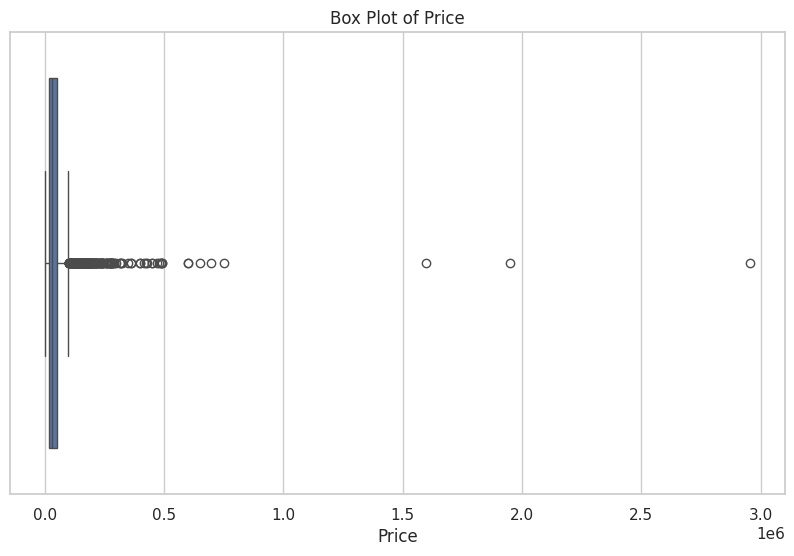

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to remove outliers
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

display(f"Original number of rows: {len(df)}")
display(f"Number of rows after removing outliers: {len(df_filtered)}")

'Original number of rows: 4009'

'Number of rows after removing outliers: 3765'

## SELECCIONAMOS SOLO LOS VALORES NÚMERICOS

In [126]:
df_clean = df.select_dtypes(include='number').copy()
df_clean

,model_year,milage,price,engine_size,fuel_type_encoded,transmission_encoded
0,2013,51000.0,10300.0,3.700000,0,0
1,2021,34742.0,38005.0,3.800000,1,1
2,2022,22372.0,54598.0,3.500000,1,1
3,2015,88900.0,15500.0,3.500000,0,0
4,2021,9835.0,34999.0,2.000000,1,1
...,...,...,...,...,...,...
4004,2023,714.0,349950.0,6.000000,1,1
4005,2022,10900.0,53900.0,3.000000,1,0
4006,2022,2116.0,90998.0,3.684454,0,1
4007,2020,33000.0,62999.0,3.500000,1,0


## CORRELACIONES

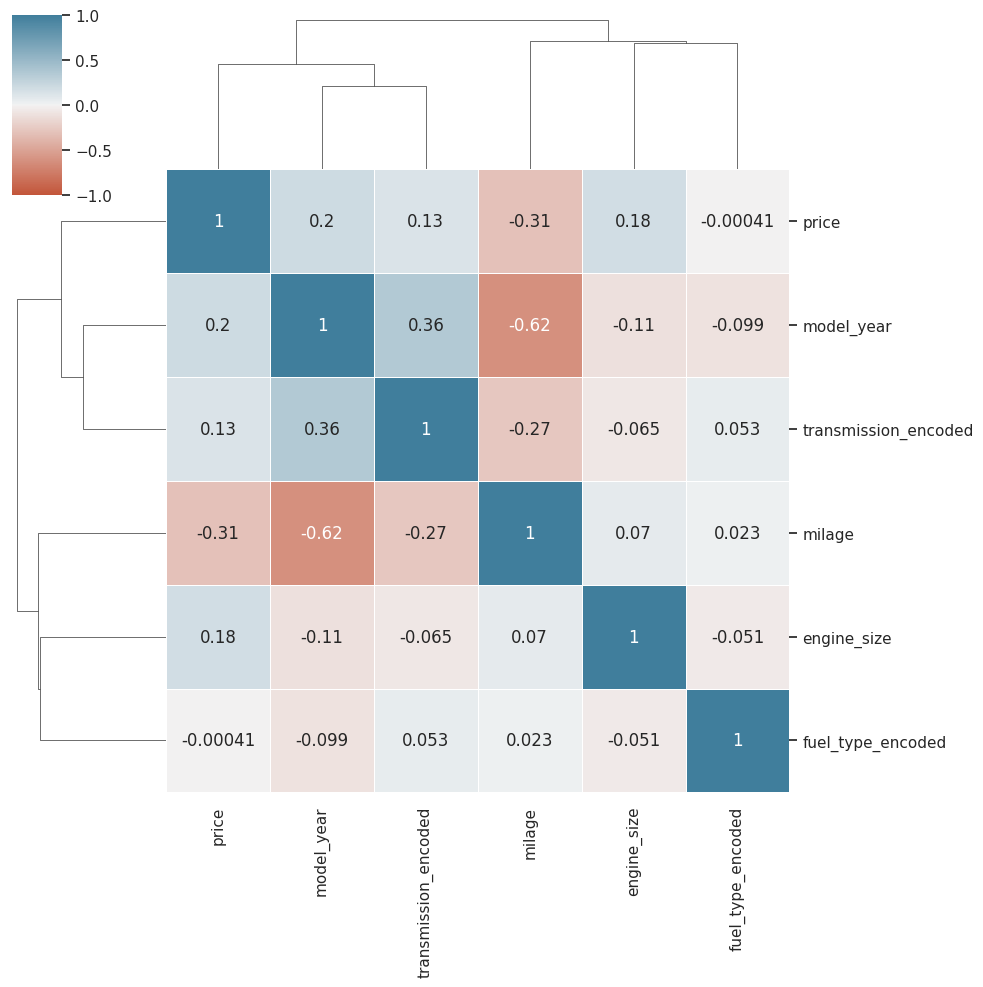

In [127]:
sns.clustermap(
    data=df_clean.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

In [128]:
df_clean = df_clean.rename(columns={'transmission_encoded': 'automatic'}).copy()

In [116]:
#df_clean = df_clean.drop(columns=['fuel_type_encoded']).copy()



In [129]:
df_clean

,model_year,milage,price,engine_size,fuel_type_encoded,automatic
0,2013,51000.0,10300.0,3.700000,0,0
1,2021,34742.0,38005.0,3.800000,1,1
2,2022,22372.0,54598.0,3.500000,1,1
3,2015,88900.0,15500.0,3.500000,0,0
4,2021,9835.0,34999.0,2.000000,1,1
...,...,...,...,...,...,...
4004,2023,714.0,349950.0,6.000000,1,1
4005,2022,10900.0,53900.0,3.000000,1,0
4006,2022,2116.0,90998.0,3.684454,0,1
4007,2020,33000.0,62999.0,3.500000,1,0


In [130]:
df_clean.to_csv('df_clean.csv', index=False)

# PASO 4  ENTRENAMIENTO DEL MODELO

# MODELOS A USAR
Regresión Lineal → modelo básico para valores continuos.

Ridge → similar a la lineal pero con regularización L2 (reduce sobreajuste).

Lasso → similar a la lineal pero con regularización L1 (puede eliminar variables poco relevantes).

Gradient Boosting → modelo basado en boosting, construye árboles secuenciales para mejorar predicciones.

In [143]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

## DEFINIMOS VARIABLE X Y Y

In [132]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# DIVIDIR DATASET EN ENTRENAMIENTO Y PRUEBA

In [138]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

# ESCALAMIENTO DE DATOS

In [139]:
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test) # Use transform on the test set

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train.values.reshape(-1, 1)) # Reshape y_train
y_test = sc_y.transform(y_test.values.reshape(-1, 1)) # Reshape y_test and use transform

# COMPARAMOS LOS MODELOS

In [149]:
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Red Neuronal (MLP)": MLPRegressor(hidden_layer_sizes=(100, ), activation='relu', solver='adam',
                                        max_iter=500, random_state=42)
}

In [150]:
# Evaluar cada modelo
def evaluar_modelo(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
    print(f'Coeficiente de Determinación (R²): {r2:.4f}')
    return r2

In [151]:
# Comparar modelos
resultados = {}
for nombre, modelo in modelos.items():
    resultados[nombre] = evaluar_modelo(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo = max(resultados, key=resultados.get)
print(f'\nEl mejor modelo es: {mejor_modelo} con un R² de {resultados[mejor_modelo]:.4f}')


Regresión Lineal:
Error Cuadrático Medio (MSE): 0.2393
Coeficiente de Determinación (R²): 0.2050

Ridge:
Error Cuadrático Medio (MSE): 0.2392
Coeficiente de Determinación (R²): 0.2051

Lasso:
Error Cuadrático Medio (MSE): 0.2339
Coeficiente de Determinación (R²): 0.2229


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest:
Error Cuadrático Medio (MSE): 0.1647
Coeficiente de Determinación (R²): 0.4526


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?



Gradient Boosting:
Error Cuadrático Medio (MSE): 0.2956
Coeficiente de Determinación (R²): 0.0177

XGBoost:
Error Cuadrático Medio (MSE): 0.1407
Coeficiente de Determinación (R²): 0.5325


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Red Neuronal (MLP):
Error Cuadrático Medio (MSE): 0.2109
Coeficiente de Determinación (R²): 0.2993

El mejor modelo es: XGBoost con un R² de 0.5325


# GRAFICAMOS RESULTADOS

/tmp/ipython-input-3932890601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')


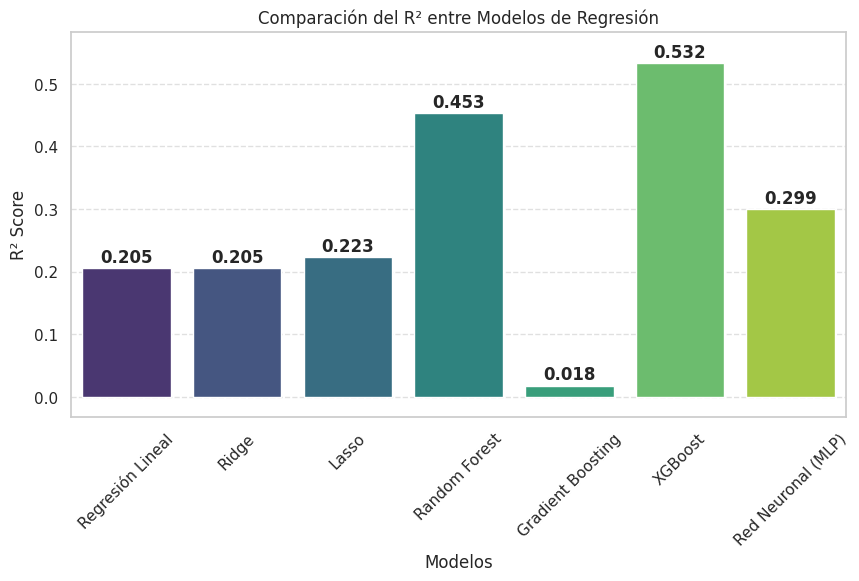

In [152]:
# Mejora en la visualización de la comparación de R²
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')

# Agregar etiquetas de los valores en las barras
for index, value in enumerate(resultados.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

# Ajustar los límites del eje Y para resaltar diferencias
plt.ylim(min(resultados.values()) - 0.05, max(resultados.values()) + 0.05)

plt.xlabel('Modelos')
plt.ylabel('R² Score')
plt.title('Comparación del R² entre Modelos de Regresión')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

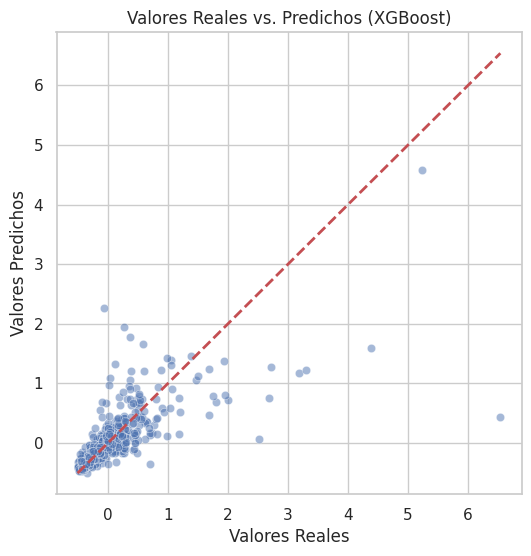

In [153]:
# Evaluación del mejor modelo seleccionado
modelo_seleccionado = modelos[mejor_modelo]
y_pred_mejor = modelo_seleccionado.predict(X_test)

# Gráfico de dispersión entre valores reales y predichos
plt.figure(figsize=(6, 6))
#sns.scatterplot(x=y_test, y=y_pred_mejor, alpha=0.5)
sns.scatterplot(x=np.ravel(y_test), y=np.ravel(y_pred_mejor), alpha=0.5)

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)  # Línea de referencia
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title(f'Valores Reales vs. Predichos ({mejor_modelo})')
plt.show()